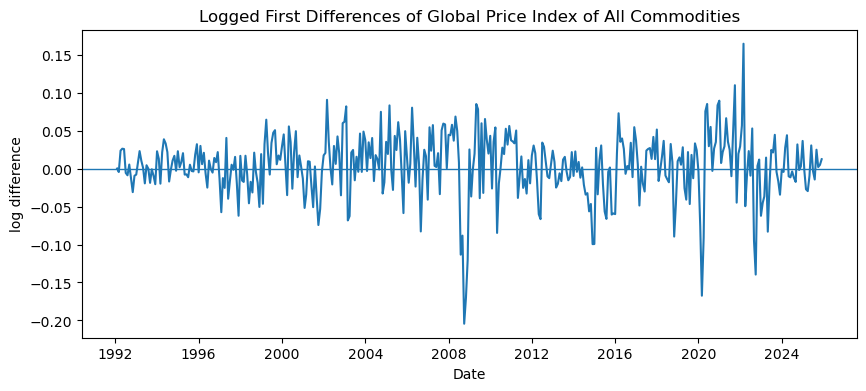

In [62]:
##Q4 i
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the original level data
df = pd.read_csv("PALLFNFINDEXM.csv")

# convert date
df["observation_date"] = pd.to_datetime(df["observation_date"])

# sort and keep data through Dec 2025
df = df.sort_values("observation_date")
df = df[df["observation_date"] <= "2025-12-01"].copy()

# drop missing level observations
df["PALLFNFINDEXM"] = pd.to_numeric(df["PALLFNFINDEXM"], errors="coerce")
df = df.dropna(subset=["PALLFNFINDEXM"])

# logged first differences
df["dlog"] = np.log(df["PALLFNFINDEXM"]).diff()

# drop first missing value created by differencing
df = df.dropna(subset=["dlog"])

# plot
plt.figure(figsize=(10, 4))
plt.plot(df["observation_date"], df["dlog"])
plt.axhline(0, linewidth=1)
plt.title("Logged First Differences of Global Price Index of All Commodities")
plt.xlabel("Date")
plt.ylabel("log difference")
plt.show()


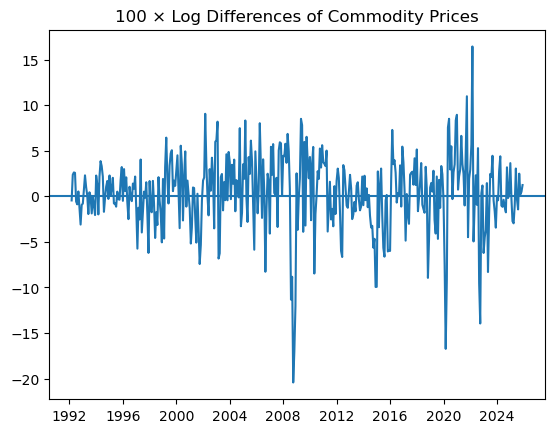

In [68]:
##Q4 i
df["dlog"] = 100 * np.log(df["PALLFNFINDEXM"]).diff()
df = df.dropna(subset=["dlog"])

plt.plot(df["observation_date"], df["dlog"])
plt.axhline(0)
plt.title("100 × Log Differences of Commodity Prices")
plt.show()

In [72]:
##Q4 ii
import numpy as np
import statsmodels.api as sm

# y = 100 * log differences from Q4(i)
y = df["dlog"].dropna().values

# number of lags
p = 12

# build lag matrix
X = np.column_stack([y[p-j:-j] for j in range(1, p+1)])
X = sm.add_constant(X)
Y = y[p:]

# run AR(12) with robust SE
res = sm.OLS(Y, X).fit(cov_type='HC1')

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     3.499
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.28e-05
Time:                        16:59:14   Log-Likelihood:                -1087.5
No. Observations:                 394   AIC:                             2201.
Df Residuals:                     381   BIC:                             2253.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2317      0.199      1.164      0.2

I estimate the AR(12) regression. 
The F-test strongly rejects the null (p-value ≈ 6.28*10^5), indicating that the series is not white noise.

AIC selects p = 24
BIC selects p = 6


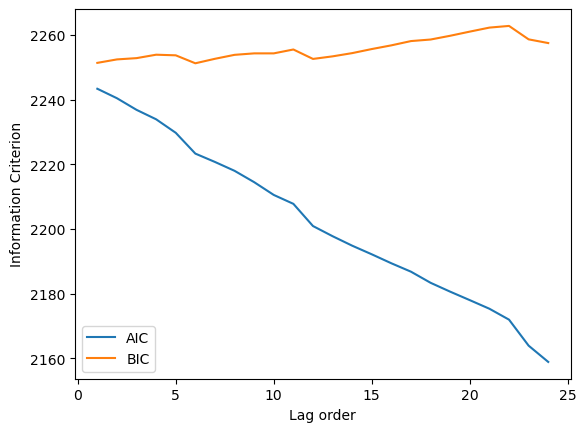

In [82]:
##Q4 iii

import numpy as np
import statsmodels.api as sm
df = df[df["observation_date"] <= "2025-12-01"]
y = df["dlog"].dropna().values

max_lag = 24
aic_vals = []
bic_vals = []

for p in range(1, max_lag + 1):
    
    X = np.column_stack([y[p-j:-j] for j in range(1, p+1)])
    X = sm.add_constant(X)
    Y = y[p:]
    
    res = sm.OLS(Y, X).fit()
    
    aic_vals.append(res.aic)
    bic_vals.append(res.bic)

# find optimal p
p_aic = np.argmin(aic_vals) + 1
p_bic = np.argmin(bic_vals) + 1

print("AIC selects p =", p_aic)
print("BIC selects p =", p_bic)

import matplotlib.pyplot as plt

lags = range(1, max_lag + 1)

plt.plot(lags, aic_vals, label="AIC")
plt.plot(lags, bic_vals, label="BIC")
plt.xlabel("Lag order")
plt.ylabel("Information Criterion")
plt.legend()
plt.show()

In [90]:
##Q4 iv
import numpy as np
import statsmodels.api as sm
df = df[df["observation_date"] <= "2025-12-01"]
y = df["dlog"].dropna().values
p = 24   # from AIC

X = np.column_stack([y[p-j:-j] for j in range(1, p+1)])
X = sm.add_constant(X)
Y = y[p:]

res = sm.OLS(Y, X).fit(cov_type="HC1")

print(res.summary())
print("Innovation variance:", res.mse_resid)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     2.263
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           0.000761
Time:                        17:39:56   Log-Likelihood:                -1054.4
No. Observations:                 382   AIC:                             2159.
Df Residuals:                     357   BIC:                             2258.
Df Model:                          24                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3038      0.207      1.465      0.1

In [105]:
##Q4 v
import pandas as pd
import numpy as np
import statsmodels.api as sm

# full dataset
df_full = pd.read_csv("PALLFNFINDEXM.csv")
df_full["observation_date"] = pd.to_datetime(df_full["observation_date"])
df_full["PALLFNFINDEXM"] = pd.to_numeric(df_full["PALLFNFINDEXM"], errors="coerce")
df_full = df_full.dropna(subset=["PALLFNFINDEXM"]).sort_values("observation_date")

# log-differenced series
df_full["dlog"] = 100 * np.log(df_full["PALLFNFINDEXM"]).diff()
df_full = df_full.dropna(subset=["dlog"])

train = df_full[df_full["observation_date"] <= "2025-12-01"].copy()

y = train["dlog"].values
X = sm.add_constant(y[:-1])
Y = y[1:]

res = sm.OLS(Y, X).fit()
c, rho = res.params

y_last = y[-1]

# forecasts
yhat_jan = c + rho * y_last
yhat_feb = c + rho * yhat_jan

print("Jan 2026 forecast:", yhat_jan)
print("Feb 2026 forecast:", yhat_feb)
actual_jan = df_full.loc[df_full["observation_date"] == "2026-01-01", "dlog"]
actual_feb = df_full.loc[df_full["observation_date"] == "2026-02-01", "dlog"]

print(actual_jan)
print(actual_feb)

y_jan = actual_jan.iloc[0]
y_feb = actual_feb.iloc[0]

err_jan = y_jan - yhat_jan
err_feb = y_feb - yhat_feb

print("Jan 2026 forecast error:", err_jan)
print("Feb 2026 forecast error:", err_feb)

Jan 2026 forecast: 0.6507519867349325
Feb 2026 forecast: 0.44172231483477165
408    5.510025
Name: dlog, dtype: float64
409    2.156599
Name: dlog, dtype: float64
Jan 2026 forecast error: 4.859272700106476
Feb 2026 forecast error: 1.7148762064594458


In [109]:
##Q4 vi
import numpy as np

# x_T = (1, last observation)
xT = np.array([1, y_last])

# covariance matrix of (const, lag1)
Sigma_hat = res.cov_params()

# innovation variance
sigma2_hat = res.mse_resid

# RMSFE
rmsfe = np.sqrt(xT @ Sigma_hat @ xT + sigma2_hat)

# 90% interval
lower = yhat_jan - 1.645 * rmsfe
upper = yhat_jan + 1.645 * rmsfe

print("90% forecast interval:", (lower, upper))

actual_jan = df_full.loc[
    df_full["observation_date"]=="2026-01-01", "dlog"
].iloc[0]

print("Actual:", actual_jan)

90% forecast interval: (-5.683927204410307, 6.985431177880172)
Actual: 5.510024686841408
